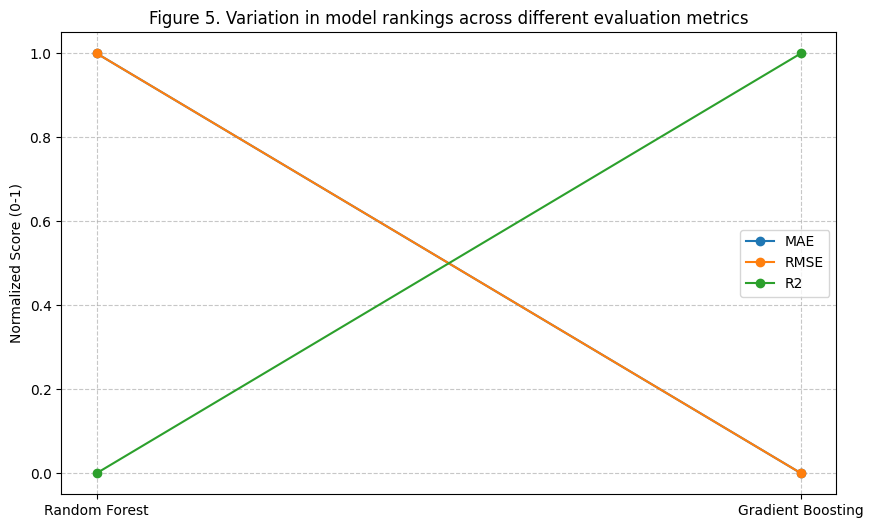

RQ5 Complete!


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load & Prep
df = pd.read_csv('/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv')
cols_to_drop = ['Campaign_ID', 'Product_ID', 'Customer_ID', 'Flash_Sale_ID', 'Bundle_ID', 'Common_Keywords']
df_clean = df.drop(columns=cols_to_drop)
df_clean = pd.get_dummies(df_clean, columns=['Subscription_Tier'], drop_first=True)

X = df_clean.drop(columns=['Revenue_Generated'])
y = df_clean['Revenue_Generated']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Models
models = {
    "Random Forest": RandomForestRegressor(random_state=42).fit(X_train, y_train),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42).fit(X_train, y_train)
}

# 3. Calculate Multiple Metrics
metrics_data = []
for name, model in models.items():
    preds = model.predict(X_test)
    metrics_data.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds)
    })

df_metrics = pd.DataFrame(metrics_data)
df_metrics.to_csv('RQ5_Metric_Comparison.csv', index=False)

# 4. Generate Figure 5: Normalized Metric Comparison
# Metrics scale alag hain, isliye normalize karke plot karenge
df_norm = df_metrics.set_index('Model')
df_norm = (df_norm - df_norm.min()) / (df_norm.max() - df_norm.min())

plt.figure(figsize=(10, 6))
for metric in ['MAE', 'RMSE', 'R2']:
    plt.plot(df_norm.index, df_norm[metric], marker='o', label=metric)

plt.title('Figure 5. Variation in model rankings across different evaluation metrics')
plt.ylabel('Normalized Score (0-1)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('RQ5_Metric_Sensitivity.pdf')
plt.show()

print("RQ5 Complete!")